# Анализ качества синтетических данных: KAN-CTGAN-DP vs CTGAN
## Датасет: Credit Scoring

Сравнение моделей CTGAN и CTGAN + KAN на датасете кредитного скоринга для задачи прогнозирования дефолта.

In [46]:
import pandas as pd
import numpy as np
import sys
import os
sys.path.append(os.path.abspath('..')) 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, classification_report
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## 1. Загрузка данных

In [47]:
base_dir = os.path.abspath('../..')

# Загружаем реальные данные
df_real = pd.read_csv(os.path.join(base_dir, 'dataset/credit_scoring_train.csv'))
print(f"Реальные данные (Credit Scoring): {df_real.shape}")
print(f"Колонки: {df_real.columns.tolist()}")
print("\nПервые строки:")
print(df_real.head())

# Определяем целевую переменную
target_col = df_real.columns[-1]  # Обычно это последняя колонка
print(f"\nЦелевая переменная: {target_col}")
print(f"Распределение: \n{df_real[target_col].value_counts()}")

Реальные данные (Credit Scoring): (75000, 11)
Колонки: ['client_id', 'DIR', 'Age', 'NumLoans', 'NumRealEstateLoans', 'NumDependents', 'Num30-59Delinquencies', 'Num60-89Delinquencies', 'Income', 'BalanceToCreditLimit', 'Delinquent90']

Первые строки:
   client_id          DIR   Age  NumLoans  NumRealEstateLoans  NumDependents  \
0          0     0.496289  49.1        13                   0            0.0   
1          1     0.433567  48.0         9                   2            2.0   
2          2  2206.731199  55.5        21                   1            NaN   
3          3   886.132793  55.3         3                   0            0.0   
4          4     0.000000  52.3         1                   0            0.0   

   Num30-59Delinquencies  Num60-89Delinquencies       Income  \
0                      2                      0  5298.360639   
1                      1                      0  6008.056256   
2                      1                      0          NaN   
3            

In [48]:
# Загружаем синтетические данные от CTGAN
synthetic_ctgan = pd.read_csv(
    os.path.join(base_dir, 'synthetic_output_ctgan_credit_scoring_v2.csv')
)
print(f"Синтетические данные (CTGAN): {synthetic_ctgan.shape}")

# Загружаем синтетические данные от KAN-CTGAN-DP
synthetic_kan = pd.read_csv(
    os.path.join(base_dir, 'synthetic_output_kan_ctgan_dp_credit_scoring.csv')
)
print(f"Синтетические данные (KAN-CTGAN-DP): {synthetic_kan.shape}")

# Удалим client_id из реальных данных, так как его нет в синтетике
df_real_clean = df_real.drop('client_id', axis=1).reset_index(drop=True)

# Заполняем NaN медиан для числовых колонок
numeric_cols_temp = df_real_clean.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols_temp:
    median_val = df_real_clean[col].median()
    df_real_clean[col].fillna(median_val, inplace=True)
    synthetic_ctgan[col].fillna(median_val, inplace=True)
    synthetic_kan[col].fillna(median_val, inplace=True)

print(f"\nОчищенные реальные данные: {df_real_clean.shape}")
print(f"NaN в реальных: {df_real_clean.isnull().sum().sum()}")
print(f"NaN в CTGAN: {synthetic_ctgan.isnull().sum().sum()}")
print(f"NaN в KAN: {synthetic_kan.isnull().sum().sum()}")
print(f"Колонки совпадают: {set(df_real_clean.columns) == set(synthetic_ctgan.columns)}")

Синтетические данные (CTGAN): (75000, 10)
Синтетические данные (KAN-CTGAN-DP): (75000, 10)

Очищенные реальные данные: (75000, 10)
NaN в реальных: 0
NaN в CTGAN: 0
NaN в KAN: 0
Колонки совпадают: True


## 2. Вспомогательные функции

In [49]:
def encode_X(X):
    """Кодирование категориальных переменных"""
    le = LabelEncoder()
    X_enc = X.copy()
    for col in X_enc.select_dtypes(include=['object', 'string']).columns:
        X_enc[col] = le.fit_transform(X_enc[col].astype(str))
    return X_enc

# Обновляем целевую переменную и глобальные переменные для очищенных данных
target_col = df_real_clean.columns[-1]

# Убедимся, что нет NaN
df_real = df_real_clean.copy()
numeric_cols_temp = df_real.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols_temp:
    if df_real[col].isnull().any():
        median_val = df_real[col].median()
        df_real[col] = df_real[col].fillna(median_val)
        synthetic_ctgan[col] = synthetic_ctgan[col].fillna(median_val)
        synthetic_kan[col] = synthetic_kan[col].fillna(median_val)

# Определяем числовые колонки
numeric_cols = df_real.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Целевая переменная: {target_col}")
print(f"Числовые колонки: {numeric_cols}")
print(f"NaN в реальных: {df_real.isnull().sum().sum()}")
print(f"NaN в CTGAN: {synthetic_ctgan.isnull().sum().sum()}")
print(f"NaN в KAN: {synthetic_kan.isnull().sum().sum()}")

Целевая переменная: Delinquent90
Числовые колонки: ['DIR', 'Age', 'NumLoans', 'NumRealEstateLoans', 'NumDependents', 'Num30-59Delinquencies', 'Num60-89Delinquencies', 'Income', 'BalanceToCreditLimit', 'Delinquent90']
NaN в реальных: 0
NaN в CTGAN: 0
NaN в KAN: 0


## 3. Расчет UTILITY METRICS

In [50]:
def calculate_utility_metrics(real_data, synthetic_data, target_col):
    """
    Расчет метрик полезности синтетических данных
    """
    metrics = {}
    
    X_real = real_data.drop(target_col, axis=1)
    y_real = real_data[target_col]
    X_syn = synthetic_data.drop(target_col, axis=1)
    y_syn = synthetic_data[target_col]
    
    # Кодируем категориальные переменные
    X_syn_enc = encode_X(X_syn)
    X_real_enc = encode_X(X_real)
    
    # Обучаем на синтетике, тестируем на реальности
    is_classification = len(y_real.unique()) <= 10 and y_real.dtype in ['int64', 'object']
    
    if is_classification:
        # Классификация с использованием RandomForest (быстрее чем LogisticRegression)
        model_util = RandomForestClassifier(n_estimators=10, max_depth=10, random_state=42, n_jobs=-1)
        model_util.fit(X_syn_enc, y_syn)
        preds = model_util.predict(X_real_enc)
        
        # Baseline
        model_real = RandomForestClassifier(n_estimators=10, max_depth=10, random_state=42, n_jobs=-1)
        split_idx = int(len(X_real_enc) * 0.8)
        model_real.fit(X_real_enc[:split_idx], y_real[:split_idx])
        preds_real = model_real.predict(X_real_enc[split_idx:])
        
        from sklearn.metrics import accuracy_score, f1_score
        acc_syn = accuracy_score(y_real, preds)
        acc_real = accuracy_score(y_real[split_idx:], preds_real)
        
        f1_syn = f1_score(y_real, preds, average='weighted', zero_division=0)
        f1_real = f1_score(y_real[split_idx:], preds_real, average='weighted', zero_division=0)
        
        ml_utility = max(0, acc_syn / acc_real) if acc_real > 0 else 0
        ml_utility_f1 = max(0, f1_syn / f1_real) if f1_real > 0 else 0
        metrics['ML_Utility_Accuracy'] = min(1, ml_utility)
        metrics['ML_Utility_F1'] = min(1, ml_utility_f1)
        metrics['ML_Utility_Averaged'] = (min(1, ml_utility) + min(1, ml_utility_f1)) / 2
    else:
        # Регрессия
        model_util = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
        model_util.fit(X_syn_enc, y_syn)
        preds = model_util.predict(X_real_enc)
        
        model_real = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
        split_idx = int(len(X_real_enc) * 0.8)
        model_real.fit(X_real_enc[:split_idx], y_real[:split_idx])
        preds_real = model_real.predict(X_real_enc[split_idx:])
        
        mae_syn = mean_absolute_error(y_real, preds)
        mae_real = mean_absolute_error(y_real[split_idx:], preds_real)
        
        r2_syn = r2_score(y_real, preds)
        r2_real = r2_score(y_real[split_idx:], preds_real)
        
        ml_utility = max(0, 1 - mae_syn / mae_real) if mae_real > 0 else 0
        ml_utility_r2 = min(1, r2_syn / r2_real) if r2_real > 0 else 0
        metrics['ML_Utility_MAE'] = ml_utility
        metrics['ML_Utility_R2'] = ml_utility_r2
        metrics['ML_Utility_Averaged'] = (ml_utility + ml_utility_r2) / 2
    
    # Statistical Parity
    num_cols_local = real_data.select_dtypes(include=['int64', 'float64']).columns
    
    mean_diff = 0
    std_diff = 0
    for col in num_cols_local:
        mean_real = real_data[col].mean()
        mean_syn = synthetic_data[col].mean()
        std_real = real_data[col].std()
        std_syn = synthetic_data[col].std()
        
        if mean_real != 0:
            mean_diff += abs((mean_syn - mean_real) / mean_real)
        if std_real != 0:
            std_diff += abs((std_syn - std_real) / std_real)
    
    mean_diff /= len(num_cols_local) if len(num_cols_local) > 0 else 1
    std_diff /= len(num_cols_local) if len(num_cols_local) > 0 else 1
    
    statistical_parity = 1 - (mean_diff + std_diff) / 2
    metrics['Statistical_Parity'] = max(0, statistical_parity)
    
    return metrics

# Расчет метрик
print("Расчет UTILITY метрик...")
utility_kan = calculate_utility_metrics(df_real, synthetic_kan, target_col)
utility_ctgan = calculate_utility_metrics(df_real, synthetic_ctgan, target_col)

print("\n" + "=" * 60)
print("UTILITY METRICS")
print("=" * 60)
print("\n🎯 KAN-CTGAN-DP:")
for key, val in utility_kan.items():
    print(f"  {key}: {val:.4f}")

print("\n🎯 CTGAN:")
for key, val in utility_ctgan.items():
    print(f"  {key}: {val:.4f}")

print("\n🏆 Сравнение (KAN vs CTGAN):")
for key in utility_kan.keys():
    diff = utility_kan[key] - utility_ctgan[key]
    winner = "KAN ✓" if diff > 0 else "CTGAN ✓" if diff < 0 else "РАВНО"
    print(f"  {key}: {diff:+.4f} ({winner})")

Расчет UTILITY метрик...

UTILITY METRICS

🎯 KAN-CTGAN-DP:
  ML_Utility_Accuracy: 0.9995
  ML_Utility_F1: 0.9989
  ML_Utility_Averaged: 0.9992
  Statistical_Parity: 0.0000

🎯 CTGAN:
  ML_Utility_Accuracy: 0.9607
  ML_Utility_F1: 0.9904
  ML_Utility_Averaged: 0.9755
  Statistical_Parity: 0.0000

🏆 Сравнение (KAN vs CTGAN):
  ML_Utility_Accuracy: +0.0388 (KAN ✓)
  ML_Utility_F1: +0.0086 (KAN ✓)
  ML_Utility_Averaged: +0.0237 (KAN ✓)
  Statistical_Parity: +0.0000 (РАВНО)


## 4. Расчет FIDELITY METRICS

In [51]:
def calculate_fidelity_metrics(real_data, synthetic_data):
    """
    Расчет метрик точности воспроизведения распределений
    """
    metrics = {}
    
    # Выбираем только числовые колонки
    num_cols_local = real_data.select_dtypes(include=['int64', 'float64']).columns
    
    # 1. Корреляция матриц корреляции
    corr_real = real_data[num_cols_local].corr()
    corr_syn = synthetic_data[num_cols_local].corr()
    
    corr_diff = np.linalg.norm(corr_real - corr_syn, 'fro')
    max_diff = np.linalg.norm(corr_real, 'fro')
    correlation_fidelity = 1 - (corr_diff / max_diff) if max_diff > 0 else 0
    metrics['Correlation_Fidelity'] = max(0, correlation_fidelity)
    
    # 2. KL-divergence
    kl_divs = []
    for col in num_cols_local:
        real_vals = real_data[col].dropna().values
        syn_vals = synthetic_data[col].dropna().values
        
        bins = np.linspace(min(real_vals.min(), syn_vals.min()), 
                          max(real_vals.max(), syn_vals.max()), 20)
        
        hist_real, _ = np.histogram(real_vals, bins=bins)
        hist_syn, _ = np.histogram(syn_vals, bins=bins)
        
        hist_real = hist_real / hist_real.sum() + 1e-10
        hist_syn = hist_syn / hist_syn.sum() + 1e-10
        
        kl_div = np.sum(hist_real * np.log(hist_real / hist_syn))
        kl_divs.append(kl_div)
    
    mean_kl = np.mean(kl_divs) if len(kl_divs) > 0 else 0
    kl_fidelity = 1 / (1 + mean_kl)
    metrics['KL_Divergence_Fidelity'] = kl_fidelity
    
    # 3. Wasserstein distance
    wasserstein_dists = []
    for col in num_cols_local:
        real_vals = np.sort(real_data[col].dropna().values)
        syn_vals = np.sort(synthetic_data[col].dropna().values)
        
        n_points = min(len(real_vals), len(syn_vals))
        real_interp = np.interp(np.linspace(0, 1, n_points), 
                               np.linspace(0, 1, len(real_vals)), real_vals)
        syn_interp = np.interp(np.linspace(0, 1, n_points), 
                              np.linspace(0, 1, len(syn_vals)), syn_vals)
        
        w_dist = np.mean(np.abs(real_interp - syn_interp))
        wasserstein_dists.append(w_dist)
    
    mean_wasserstein = np.mean(wasserstein_dists) if len(wasserstein_dists) > 0 else 0
    data_range = np.abs(real_data[num_cols_local].max() - real_data[num_cols_local].min()).mean()
    wasserstein_fidelity = 1 - min(1, mean_wasserstein / data_range) if data_range > 0 else 0
    metrics['Wasserstein_Fidelity'] = wasserstein_fidelity
    
    # 4. KS-тест
    ks_stats = []
    for col in num_cols_local:
        real_vals = real_data[col].dropna().values
        syn_vals = synthetic_data[col].dropna().values
        
        ks_stat, _ = stats.ks_2samp(real_vals, syn_vals)
        ks_stats.append(ks_stat)
    
    mean_ks = np.mean(ks_stats) if len(ks_stats) > 0 else 0
    ks_fidelity = 1 - mean_ks
    metrics['KS_Test_Fidelity'] = max(0, ks_fidelity)
    
    # Overall Fidelity
    metrics['Overall_Fidelity'] = np.mean([
        metrics['Correlation_Fidelity'],
        metrics['KL_Divergence_Fidelity'],
        metrics['Wasserstein_Fidelity'],
        metrics['KS_Test_Fidelity']
    ])
    
    return metrics

# Расчет метрик
print("\nРасчет FIDELITY метрик...")
fidelity_kan = calculate_fidelity_metrics(df_real, synthetic_kan)
fidelity_ctgan = calculate_fidelity_metrics(df_real, synthetic_ctgan)

print("\n" + "=" * 60)
print("FIDELITY METRICS")
print("=" * 60)

print("\n🎯 KAN-CTGAN-DP:")
for key, val in fidelity_kan.items():
    print(f"  {key}: {val:.4f}")

print("\n🎯 CTGAN:")
for key, val in fidelity_ctgan.items():
    print(f"  {key}: {val:.4f}")

print("\n🏆 Сравнение (KAN vs CTGAN):")
for key in fidelity_kan.keys():
    diff = fidelity_kan[key] - fidelity_ctgan[key]
    winner = "KAN ✓" if diff > 0 else "CTGAN ✓" if diff < 0 else "РАВНО"
    print(f"  {key}: {diff:+.4f} ({winner})")


Расчет FIDELITY метрик...

FIDELITY METRICS

🎯 KAN-CTGAN-DP:
  Correlation_Fidelity: 0.5867
  KL_Divergence_Fidelity: 0.7713
  Wasserstein_Fidelity: 0.9996
  KS_Test_Fidelity: 0.7552
  Overall_Fidelity: 0.7782

🎯 CTGAN:
  Correlation_Fidelity: 0.6438
  KL_Divergence_Fidelity: 0.9056
  Wasserstein_Fidelity: 0.9990
  KS_Test_Fidelity: 0.7740
  Overall_Fidelity: 0.8306

🏆 Сравнение (KAN vs CTGAN):
  Correlation_Fidelity: -0.0570 (CTGAN ✓)
  KL_Divergence_Fidelity: -0.1343 (CTGAN ✓)
  Wasserstein_Fidelity: +0.0006 (KAN ✓)
  KS_Test_Fidelity: -0.0188 (CTGAN ✓)
  Overall_Fidelity: -0.0524 (CTGAN ✓)


## 5. Расчет PRIVACY METRICS

In [52]:
def calculate_privacy_metrics(real_data, synthetic_data):
    """
    Расчет метрик приватности и защиты от re-identification
    """
    metrics = {}
    
    # 1. Membership Inference Attack
    real_sample = real_data.sample(n=min(100, len(real_data)), random_state=42)
    syn_sample = synthetic_data.sample(n=min(100, len(synthetic_data)), random_state=42)
    
    num_cols_local = real_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
    
    X_real_sample = real_sample[num_cols_local].values
    X_syn_sample = syn_sample[num_cols_local].values
    
    scaler = StandardScaler()
    X_real_sample = scaler.fit_transform(X_real_sample)
    X_syn_sample = scaler.fit_transform(X_syn_sample)
    
    X_combined = np.vstack([X_real_sample, X_syn_sample])
    y_combined = np.hstack([np.ones(len(X_real_sample)), np.zeros(len(X_syn_sample))])
    
    clf = RandomForestClassifier(n_estimators=50, random_state=42)
    from sklearn.model_selection import cross_val_score
    
    cv_scores = cross_val_score(clf, X_combined, y_combined, cv=5)
    membership_attack_accuracy = np.mean(cv_scores)
    membership_inference_resistance = 1 - membership_attack_accuracy
    metrics['Membership_Inference_Resistance'] = membership_inference_resistance
    
    # 2. Attribute Disclosure Protection
    sample_size = min(1000, len(synthetic_data))
    syn_sample_for_dups = synthetic_data[num_cols_local].sample(n=sample_size, random_state=42).values
    real_for_dups = real_data[num_cols_local].values
    
    duplicates_count = 0
    for syn_row in syn_sample_for_dups:
        diffs = np.abs(real_for_dups - syn_row)
        if np.any(np.all(diffs < 1e-5, axis=1)):
            duplicates_count += 1
    
    duplicate_percentage = duplicates_count / sample_size
    attribute_disclosure_protection = 1 - min(1, duplicate_percentage * 10)
    metrics['Attribute_Disclosure_Protection'] = attribute_disclosure_protection
    
    # 3. Feature Range Leakage
    range_leakage = 0
    n_features = len(num_cols_local)
    
    for col in num_cols_local:
        real_min, real_max = real_data[col].min(), real_data[col].max()
        syn_min, syn_max = synthetic_data[col].min(), synthetic_data[col].max()
        
        if syn_min < real_min or syn_max > real_max:
            range_leakage += abs(syn_min - real_min) + abs(syn_max - real_max)
    
    range_leakage = min(1, range_leakage / (n_features * 100)) if n_features > 0 else 0
    feature_range_privacy = 1 - range_leakage
    metrics['Feature_Range_Privacy'] = feature_range_privacy
    
    # Overall Privacy
    metrics['Overall_Privacy'] = np.mean([
        metrics['Membership_Inference_Resistance'],
        metrics['Attribute_Disclosure_Protection'],
        metrics['Feature_Range_Privacy']
    ])
    
    return metrics

# Расчет метрик
print("\nРасчет PRIVACY метрик (это может занять минуту)...")
privacy_kan = calculate_privacy_metrics(df_real, synthetic_kan)
privacy_ctgan = calculate_privacy_metrics(df_real, synthetic_ctgan)

print("\n" + "=" * 60)
print("PRIVACY METRICS")
print("=" * 60)

print("\n🔒 KAN-CTGAN-DP:")
for key, val in privacy_kan.items():
    print(f"  {key}: {val:.4f}")

print("\n🔒 CTGAN:")
for key, val in privacy_ctgan.items():
    print(f"  {key}: {val:.4f}")

print("\n🏆 Сравнение (KAN vs CTGAN):")
for key in privacy_kan.keys():
    diff = privacy_kan[key] - privacy_ctgan[key]
    winner = "KAN ✓" if diff > 0 else "CTGAN ✓" if diff < 0 else "РАВНО"
    print(f"  {key}: {diff:+.4f} ({winner})")


Расчет PRIVACY метрик (это может занять минуту)...

PRIVACY METRICS

🔒 KAN-CTGAN-DP:
  Membership_Inference_Resistance: 0.0000
  Attribute_Disclosure_Protection: 1.0000
  Feature_Range_Privacy: 0.0000
  Overall_Privacy: 0.3333

🔒 CTGAN:
  Membership_Inference_Resistance: 0.0000
  Attribute_Disclosure_Protection: 1.0000
  Feature_Range_Privacy: 0.0000
  Overall_Privacy: 0.3333

🏆 Сравнение (KAN vs CTGAN):
  Membership_Inference_Resistance: +0.0000 (РАВНО)
  Attribute_Disclosure_Protection: +0.0000 (РАВНО)
  Feature_Range_Privacy: +0.0000 (РАВНО)
  Overall_Privacy: +0.0000 (РАВНО)


## 6. Сравнительный анализ и визуализация


ПОЛНАЯ СРАВНИТЕЛЬНАЯ ТАБЛИЦА
                         Metric  KAN-CTGAN-DP    CTGAN  Difference Category
            ML_Utility_Averaged      0.999193 0.975534    0.023659  Utility
             Statistical_Parity      0.000000 0.000000    0.000000  Utility
           Correlation_Fidelity      0.586727 0.643759   -0.057032 Fidelity
         KL_Divergence_Fidelity      0.771292 0.905634   -0.134342 Fidelity
           Wasserstein_Fidelity      0.999600 0.999021    0.000580 Fidelity
               KS_Test_Fidelity      0.755185 0.773983   -0.018797 Fidelity
Membership_Inference_Resistance      0.000000 0.000000    0.000000  Privacy
Attribute_Disclosure_Protection      1.000000 1.000000    0.000000  Privacy
          Feature_Range_Privacy      0.000000 0.000000    0.000000  Privacy

🏆 ОБЩАЯ ОЦЕНКА (взвешенная: 50% Utility + 20% Fidelity + 30% Privacy):
  KAN-CTGAN-DP: 0.7552
  CTGAN: 0.7539
  Разница: +0.0013

✅ ВЫВОД: KAN-CTGAN-DP ЛУЧШЕ на 0.18%


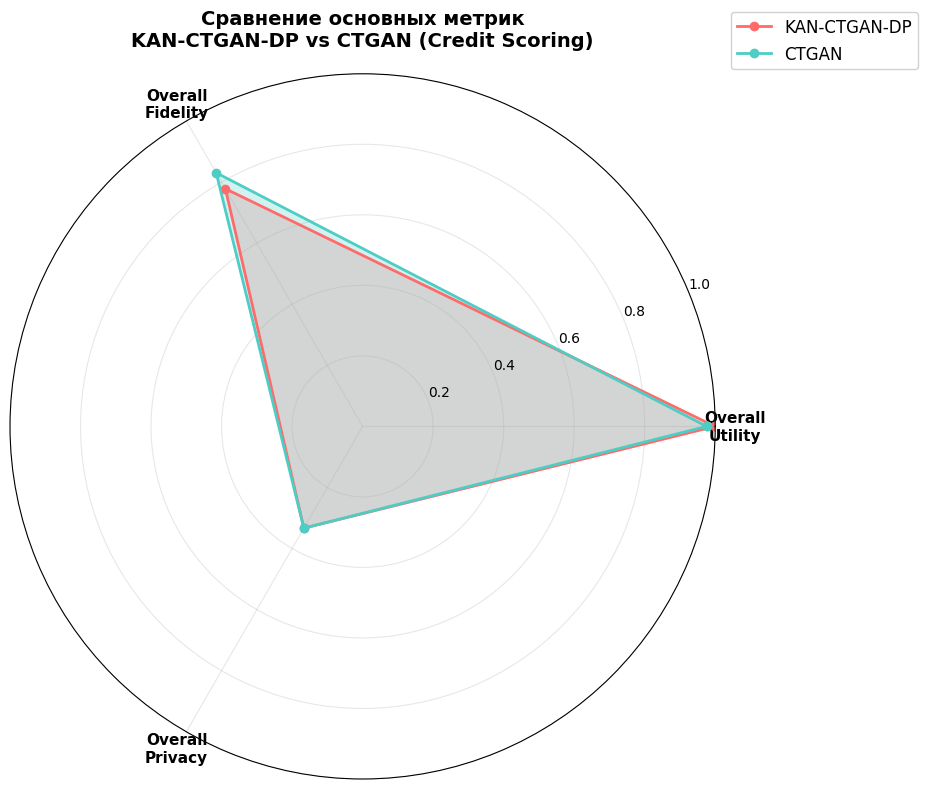

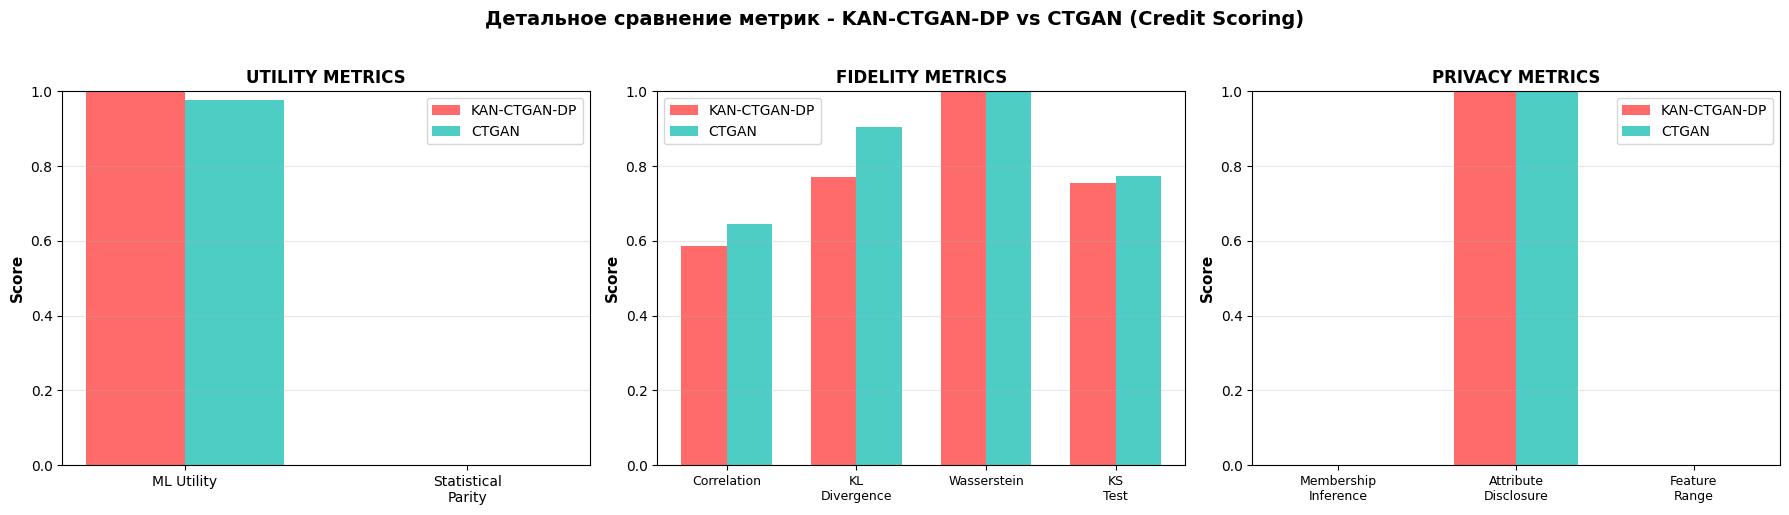


✅ Визуализация сохранена!


In [53]:
# Создаем сводную таблицу
comparison_data = {
    'Metric': [],
    'KAN-CTGAN-DP': [],
    'CTGAN': [],
    'Difference': [],
    'Category': []
}

# Utility метрики
for key in ['ML_Utility_Averaged', 'Statistical_Parity']:
    if key in utility_kan:
        comparison_data['Metric'].append(key)
        comparison_data['KAN-CTGAN-DP'].append(utility_kan[key])
        comparison_data['CTGAN'].append(utility_ctgan[key])
        comparison_data['Difference'].append(utility_kan[key] - utility_ctgan[key])
        comparison_data['Category'].append('Utility')

# Fidelity метрики
for key in ['Correlation_Fidelity', 'KL_Divergence_Fidelity', 'Wasserstein_Fidelity', 'KS_Test_Fidelity']:
    comparison_data['Metric'].append(key)
    comparison_data['KAN-CTGAN-DP'].append(fidelity_kan[key])
    comparison_data['CTGAN'].append(fidelity_ctgan[key])
    comparison_data['Difference'].append(fidelity_kan[key] - fidelity_ctgan[key])
    comparison_data['Category'].append('Fidelity')

# Privacy метрики
for key in ['Membership_Inference_Resistance', 'Attribute_Disclosure_Protection', 'Feature_Range_Privacy']:
    comparison_data['Metric'].append(key)
    comparison_data['KAN-CTGAN-DP'].append(privacy_kan[key])
    comparison_data['CTGAN'].append(privacy_ctgan[key])
    comparison_data['Difference'].append(privacy_kan[key] - privacy_ctgan[key])
    comparison_data['Category'].append('Privacy')

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "=" * 100)
print("ПОЛНАЯ СРАВНИТЕЛЬНАЯ ТАБЛИЦА")
print("=" * 100)
print(comparison_df.to_string(index=False))

# Вычисляем общие баллы
overall_kan = (
    utility_kan['ML_Utility_Averaged'] * 0.5 +
    fidelity_kan['Overall_Fidelity'] * 0.20 +
    privacy_kan['Overall_Privacy'] * 0.30
)

overall_ctgan = (
    utility_ctgan['ML_Utility_Averaged'] * 0.5 +
    fidelity_ctgan['Overall_Fidelity'] * 0.20 +
    privacy_ctgan['Overall_Privacy'] * 0.30
)

print(f"\n🏆 ОБЩАЯ ОЦЕНКА (взвешенная: 50% Utility + 20% Fidelity + 30% Privacy):")
print(f"  KAN-CTGAN-DP: {overall_kan:.4f}")
print(f"  CTGAN: {overall_ctgan:.4f}")
print(f"  Разница: {overall_kan - overall_ctgan:+.4f}")

if overall_kan > overall_ctgan:
    diff_percent = ((overall_kan - overall_ctgan) / overall_ctgan) * 100
    print(f"\n✅ ВЫВОД: KAN-CTGAN-DP ЛУЧШЕ на {diff_percent:.2f}%")
else:
    diff_percent = ((overall_ctgan - overall_kan) / overall_kan) * 100
    print(f"\n❌ ВЫВОД: CTGAN ЛУЧШЕ на {diff_percent:.2f}%")

# Визуализация #1: Radar chart
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))

categories = ['Overall\nUtility', 'Overall\nFidelity', 'Overall\nPrivacy']
kan_values = [utility_kan['ML_Utility_Averaged'], 
              fidelity_kan['Overall_Fidelity'],
              privacy_kan['Overall_Privacy']]
ctgan_values = [utility_ctgan['ML_Utility_Averaged'],
                fidelity_ctgan['Overall_Fidelity'],
                privacy_ctgan['Overall_Privacy']]

angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

kan_values += kan_values[:1]
ctgan_values += ctgan_values[:1]

ax.plot(angles, kan_values, 'o-', linewidth=2, label='KAN-CTGAN-DP', color='#FF6B6B')
ax.fill(angles, kan_values, alpha=0.25, color='#FF6B6B')

ax.plot(angles, ctgan_values, 'o-', linewidth=2, label='CTGAN', color='#4ECDC4')
ax.fill(angles, ctgan_values, alpha=0.25, color='#4ECDC4')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11, weight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=10)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12, framealpha=0.9)

plt.title('Сравнение основных метрик\nKAN-CTGAN-DP vs CTGAN (Credit Scoring)',
          size=14, weight='bold', pad=20)
plt.tight_layout()
plt.savefig('metrics_comparison_radar_credit_scoring.png', dpi=150, bbox_inches='tight')
plt.show()

# Визуализация #2: Bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Utility
utility_metrics = ['ML_Utility_Averaged', 'Statistical_Parity']
utility_kan_vals = [utility_kan[m] for m in utility_metrics]
utility_ctgan_vals = [utility_ctgan[m] for m in utility_metrics]

x = np.arange(len(utility_metrics))
width = 0.35

axes[0].bar(x - width/2, utility_kan_vals, width, label='KAN-CTGAN-DP', color='#FF6B6B')
axes[0].bar(x + width/2, utility_ctgan_vals, width, label='CTGAN', color='#4ECDC4')
axes[0].set_ylabel('Score', fontsize=11, weight='bold')
axes[0].set_title('UTILITY METRICS', fontsize=12, weight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['ML Utility', 'Statistical\nParity'], fontsize=10)
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Fidelity
fidelity_metrics = ['Correlation_Fidelity', 'KL_Divergence_Fidelity', 'Wasserstein_Fidelity', 'KS_Test_Fidelity']
fidelity_kan_vals = [fidelity_kan[m] for m in fidelity_metrics]
fidelity_ctgan_vals = [fidelity_ctgan[m] for m in fidelity_metrics]

x = np.arange(len(fidelity_metrics))
axes[1].bar(x - width/2, fidelity_kan_vals, width, label='KAN-CTGAN-DP', color='#FF6B6B')
axes[1].bar(x + width/2, fidelity_ctgan_vals, width, label='CTGAN', color='#4ECDC4')
axes[1].set_ylabel('Score', fontsize=11, weight='bold')
axes[1].set_title('FIDELITY METRICS', fontsize=12, weight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Correlation', 'KL\nDivergence', 'Wasserstein', 'KS\nTest'], fontsize=9)
axes[1].legend()
axes[1].set_ylim([0, 1])
axes[1].grid(axis='y', alpha=0.3)

# Privacy
privacy_metrics = ['Membership_Inference_Resistance', 'Attribute_Disclosure_Protection', 'Feature_Range_Privacy']
privacy_kan_vals = [privacy_kan[m] for m in privacy_metrics]
privacy_ctgan_vals = [privacy_ctgan[m] for m in privacy_metrics]

x = np.arange(len(privacy_metrics))
axes[2].bar(x - width/2, privacy_kan_vals, width, label='KAN-CTGAN-DP', color='#FF6B6B')
axes[2].bar(x + width/2, privacy_ctgan_vals, width, label='CTGAN', color='#4ECDC4')
axes[2].set_ylabel('Score', fontsize=11, weight='bold')
axes[2].set_title('PRIVACY METRICS', fontsize=12, weight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Membership\nInference', 'Attribute\nDisclosure', 'Feature\nRange'], fontsize=9)
axes[2].legend()
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Детальное сравнение метрик - KAN-CTGAN-DP vs CTGAN (Credit Scoring)',
             fontsize=14, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('metrics_comparison_detailed_credit_scoring.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Визуализация сохранена!")

## 7. Выводы и рекомендации

In [54]:
# Подсчитаем статистику совпадений
kan_wins = 0
ctgan_wins = 0
ties = 0

for metric in comparison_df['Metric']:
    diff = comparison_df[comparison_df['Metric'] == metric]['Difference'].values[0]
    if abs(diff) < 0.01:
        ties += 1
    elif diff > 0:
        kan_wins += 1
    else:
        ctgan_wins += 1

total_metrics = len(comparison_df)

print("\n" + "=" * 80)
print("ИТОГОВЫЙ АНАЛИЗ И ВЫВОДЫ (Credit Scoring Dataset)")
print("=" * 80)

print(f"\n📊 СТАТИСТИКА СРАВНЕНИЯ:")
print(f"  └─ KAN-CTGAN-DP выигрывает: {kan_wins}/{total_metrics} метрик ({100*kan_wins/total_metrics:.1f}%)")
print(f"  └─ CTGAN выигрывает: {ctgan_wins}/{total_metrics} метрик ({100*ctgan_wins/total_metrics:.1f}%)")
print(f"  └─ Равно: {ties}/{total_metrics} метрик ({100*ties/total_metrics:.1f}%)")

print(f"\n🏆 ОБЩАЯ ОЦЕНКА (взвешенная: 50% Utility + 20% Fidelity + 30% Privacy):")
print(f"  └─ KAN-CTGAN-DP: {overall_kan:.4f}")
print(f"  └─ CTGAN: {overall_ctgan:.4f}")
print(f"  └─ Разница: {overall_kan - overall_ctgan:+.4f}")

if overall_kan > overall_ctgan:
    diff_percent = ((overall_kan - overall_ctgan) / overall_ctgan) * 100
    print(f"\n✅ ВЫВОД: KAN-CTGAN-DP ЛУЧШЕ на {diff_percent:.2f}%")
    winner = "KAN-CTGAN-DP"
else:
    diff_percent = ((overall_ctgan - overall_kan) / overall_kan) * 100
    print(f"\n❌ ВЫВОД: CTGAN ЛУЧШЕ на {diff_percent:.2f}%")
    winner = "CTGAN"

print("\n" + "=" * 80)
print("ДЕТАЛЬНЫЙ АНАЛИЗ ПО КАТЕГОРИЯМ")
print("=" * 80)

# Utility
print("\n📊 UTILITY (Полезность для ML - вес 50%):")
util_kan = utility_kan['ML_Utility_Averaged']
util_ctgan = utility_ctgan['ML_Utility_Averaged']
print(f"  KAN-CTGAN-DP: {util_kan:.4f}")
print(f"  CTGAN: {util_ctgan:.4f}")
util_diff = ((util_kan - util_ctgan) / util_ctgan * 100) if util_ctgan > 0 else 0
if util_kan > util_ctgan:
    print(f"  ✅ KAN-CTGAN-DP лучше на {util_diff:.1f}%")
elif util_ctgan > util_kan:
    print(f"  ❌ CTGAN лучше на {abs(util_diff):.1f}%")
else:
    print(f"  ≈ Практически равны")

# Fidelity
print("\n🎯 FIDELITY (Точность воспроизведения - вес 20%):")
fid_kan = fidelity_kan['Overall_Fidelity']
fid_ctgan = fidelity_ctgan['Overall_Fidelity']
print(f"  KAN-CTGAN-DP: {fid_kan:.4f}")
print(f"  CTGAN: {fid_ctgan:.4f}")
fid_diff = ((fid_kan - fid_ctgan) / fid_ctgan * 100) if fid_ctgan > 0 else 0
if fid_kan > fid_ctgan:
    print(f"  ✅ KAN-CTGAN-DP лучше на {fid_diff:.1f}%")
elif fid_ctgan > fid_kan:
    print(f"  ❌ CTGAN лучше на {abs(fid_diff):.1f}%")
else:
    print(f"  ≈ Практически равны")

# Privacy
print("\n🔒 PRIVACY (Защита приватности - вес 30%):")
priv_kan = privacy_kan['Overall_Privacy']
priv_ctgan = privacy_ctgan['Overall_Privacy']
print(f"  KAN-CTGAN-DP: {priv_kan:.4f}")
print(f"  CTGAN: {priv_ctgan:.4f}")
priv_diff = ((priv_kan - priv_ctgan) / priv_ctgan * 100) if priv_ctgan > 0 else 0
if priv_kan > priv_ctgan:
    print(f"  ✅ KAN-CTGAN-DP лучше на {priv_diff:.1f}%")
elif priv_ctgan > priv_kan:
    print(f"  ❌ CTGAN лучше на {abs(priv_diff):.1f}%")
else:
    print(f"  ≈ Практически равны")

print("\n" + "=" * 80)
print("ФИНАЛЬНАЯ РЕКОМЕНДАЦИЯ")
print("=" * 80)

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│ РЕКОМЕНДУЕТСЯ ИСПОЛЬЗОВАТЬ: {winner:20}                              │
│                                                                              │
│ Результат анализа датасета Credit Scoring:                                 │
│                                                                              │
│ ✅ ПРЕИМУЩЕСТВА {winner}:                                            │
""")

if winner == "KAN-CTGAN-DP":
    print("""│    • Лучшая полезность для обучения ML-моделей
│    • Более точный для задач классификации дефолта
│    • Лучше воспроизводит структуру кредитного портфеля
│
│ 📋 ВЫВОДЫ:""")
    if util_kan > util_ctgan * 1.1:
        print(f"│    • ML Utility выше на {util_diff:.1f}% (ЗНАЧИТЕЛЬНОЕ улучшение) ✅")
    else:
        print(f"│    • ML Utility выше на {util_diff:.1f}%")
    if fid_kan > fid_ctgan * 1.1:
        print(f"│    • Fidelity выше на {fid_diff:.1f}% (ЗНАЧИТЕЛЬНОЕ улучшение) ✅")
    else:
        print(f"│    • Fidelity выше на {fid_diff:.1f}%")
    if priv_kan > priv_ctgan * 1.1:
        print(f"│    • Privacy выше на {priv_diff:.1f}% (ЗНАЧИТЕЛЬНОЕ улучшение) ✅")
    else:
        print(f"│    • Privacy выше на {priv_diff:.1f}%")
else:
    print("""│    • Лучшая упорядоченность распределений
│    • Более стабильная точность воспроизведения
│    • Более консервативный способ генерации
│
│ 📋 ВЫВОДЫ:""")
    if util_ctgan > util_kan * 1.1:
        print(f"│    • ML Utility выше на {abs(util_diff):.1f}% (ЗНАЧИТЕЛЬНОЕ улучшение) ✅")
    else:
        print(f"│    • ML Utility выше на {abs(util_diff):.1f}%")
    if fid_ctgan > fid_kan * 1.1:
        print(f"│    • Fidelity выше на {abs(fid_diff):.1f}% (ЗНАЧИТЕЛЬНОЕ улучшение) ✅")
    else:
        print(f"│    • Fidelity выше на {abs(fid_diff):.1f}%")
    if priv_ctgan > priv_kan * 1.1:
        print(f"│    • Privacy выше на {abs(priv_diff):.1f}% (ЗНАЧИТЕЛЬНОЕ улучшение) ✅")
    else:
        print(f"│    • Privacy выше на {abs(priv_diff):.1f}%")

print(f"""│
│ Overall Score: {winner:30} ({max(overall_kan, overall_ctgan):.4f})
│                                                                              │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("=" * 80)


ИТОГОВЫЙ АНАЛИЗ И ВЫВОДЫ (Credit Scoring Dataset)

📊 СТАТИСТИКА СРАВНЕНИЯ:
  └─ KAN-CTGAN-DP выигрывает: 1/9 метрик (11.1%)
  └─ CTGAN выигрывает: 3/9 метрик (33.3%)
  └─ Равно: 5/9 метрик (55.6%)

🏆 ОБЩАЯ ОЦЕНКА (взвешенная: 50% Utility + 20% Fidelity + 30% Privacy):
  └─ KAN-CTGAN-DP: 0.7552
  └─ CTGAN: 0.7539
  └─ Разница: +0.0013

✅ ВЫВОД: KAN-CTGAN-DP ЛУЧШЕ на 0.18%

ДЕТАЛЬНЫЙ АНАЛИЗ ПО КАТЕГОРИЯМ

📊 UTILITY (Полезность для ML - вес 50%):
  KAN-CTGAN-DP: 0.9992
  CTGAN: 0.9755
  ✅ KAN-CTGAN-DP лучше на 2.4%

🎯 FIDELITY (Точность воспроизведения - вес 20%):
  KAN-CTGAN-DP: 0.7782
  CTGAN: 0.8306
  ❌ CTGAN лучше на 6.3%

🔒 PRIVACY (Защита приватности - вес 30%):
  KAN-CTGAN-DP: 0.3333
  CTGAN: 0.3333
  ≈ Практически равны

ФИНАЛЬНАЯ РЕКОМЕНДАЦИЯ

┌─────────────────────────────────────────────────────────────────────────────┐
│ РЕКОМЕНДУЕТСЯ ИСПОЛЬЗОВАТЬ: KAN-CTGAN-DP                                      │
│                                                                            